In [2]:
# Cell 1 - Import library dan konfigurasi utama

from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

warnings.filterwarnings("ignore")


# ============================================================
# INPUT CONFIG
# ============================================================

# Base hasil preprocessing GC25 + ZT0.08
# Catatan: folder utama masih bernama Preprocessed_GC25_Z008,
# tetapi folder ZT yang benar adalah GC25_Z080 karena 0.08 m = 80 mm.
PREPROC_BASE_DIR = Path("/media/spell/Spell-lab/Lidar/D.Preprocessing") / "Preprocessed_GC25_Z008"

DBSCAN_INPUT_DIR = PREPROC_BASE_DIR / "GC25_Z080"


# ============================================================
# OUTPUT CONFIG
# ============================================================

DBSCAN_OUT_DIR = Path("/media/spell/Spell-lab/Lidar/D.Preprocessing") / "DBSCAN_Calibration_GC25_Z080"

METRICS_DIR = DBSCAN_OUT_DIR / "_metrics"
LOG_DIR = DBSCAN_OUT_DIR / "_logs"
FIG_DIR = DBSCAN_OUT_DIR / "_figures"


# ============================================================
# DBSCAN PARAMETER GRID
# ============================================================

EPS_LIST = [0.08, 0.10, 0.12, 0.15, 0.18, 0.20]
MIN_SAMPLES_LIST = [10, 15, 20, 25]

MIN_CLUSTER_POINTS = 20

DBSCAN_FEATURES = ["X_corr", "Y_corr", "Z_level"]

CORR_ZERO_CHECK_COLUMNS = ["X_corr", "Y_corr", "Z_corr"]
RAW_ZERO_CHECK_COLUMNS = ["X", "Y", "Z"]
FINITE_CHECK_COLUMNS = ["X_corr", "Y_corr", "Z_corr", "Z_level"]


# ============================================================
# DATA CLEANING CONFIG
# ============================================================

REMOVE_NON_FINITE = True
REMOVE_ALL_ZERO_COORDS = True
DEGENERATE_EPS = 1e-6


# ============================================================
# DATASET CONFIG
# ============================================================

ACTIVITIES = ["Bungkuk", "Duduk", "Jongkok", "Jatuh"]

DEV_SUBJECTS = [
    "Adelia",
    "Afi",
    "Aswangga",
    "Bustan",
    "Dilia",
    "Eldivo",
    "Fathir",
    "Lina",
    "Manda",
    "Miftah",
    "Teguh",
    "Tsamara",
]

TEST_ROOMS = ["Controlled Room", "Uncontrolled Room"]

TEST_SUBJECTS = [
    "Kanaya",
    "Naila",
    "Nana",
    "Rega",
    "Zaira",
]

FILE_IDS = list(range(1, 10))


# ============================================================
# REQUIRED INPUT COLUMNS
# ============================================================

REQUIRED_COLUMNS = [
    "frame_id",
    "Timestamp",
    "X",
    "Y",
    "Z",
    "X_corr",
    "Y_corr",
    "Z_corr",
    "Z_level",
    "Reflectivity",
]


# ============================================================
# ROI AXIS RANGE UNTUK VISUALISASI
# ============================================================

ROI_X_MIN, ROI_X_MAX = 0.0, 3.0
ROI_Y_MIN, ROI_Y_MAX = -1.5, 1.5
ROI_Z_MIN, ROI_Z_MAX = 0.0, 2.0


# ============================================================
# OUTPUT BEHAVIOR
# ============================================================

OVERWRITE_METRICS = True
FLOAT_FORMAT = "%.6f"


print("===== DBSCAN TUNING CONFIG =====")
print(f"Input dir          : {DBSCAN_INPUT_DIR}")
print(f"Output dir         : {DBSCAN_OUT_DIR}")
print(f"Features           : {DBSCAN_FEATURES}")
print(f"EPS_LIST           : {EPS_LIST}")
print(f"MIN_SAMPLES_LIST   : {MIN_SAMPLES_LIST}")
print(f"MIN_CLUSTER_POINTS : {MIN_CLUSTER_POINTS}")
print(f"Remove non-finite  : {REMOVE_NON_FINITE}")
print(f"Remove all-zero    : {REMOVE_ALL_ZERO_COORDS}")
print(f"Degenerate eps     : {DEGENERATE_EPS}")

===== DBSCAN TUNING CONFIG =====
Input dir          : /media/spell/Spell-lab/Lidar/D.Preprocessing/Preprocessed_GC25_Z008/GC25_Z080
Output dir         : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080
Features           : ['X_corr', 'Y_corr', 'Z_level']
EPS_LIST           : [0.08, 0.1, 0.12, 0.15, 0.18, 0.2]
MIN_SAMPLES_LIST   : [10, 15, 20, 25]
MIN_CLUSTER_POINTS : 20
Remove non-finite  : True
Remove all-zero    : True
Degenerate eps     : 1e-06


In [3]:
# Cell 2 - Membuat folder output dan menyimpan konfigurasi

for d in [DBSCAN_OUT_DIR, METRICS_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

config = {
    "input_dir": str(DBSCAN_INPUT_DIR),
    "output_dir": str(DBSCAN_OUT_DIR),
    "dbscan_features": DBSCAN_FEATURES,
    "eps_list": EPS_LIST,
    "min_samples_list": MIN_SAMPLES_LIST,
    "min_cluster_points": MIN_CLUSTER_POINTS,
    "cleaning": {
        "remove_non_finite": REMOVE_NON_FINITE,
        "remove_all_zero_coords": REMOVE_ALL_ZERO_COORDS,
        "degenerate_eps": DEGENERATE_EPS,
        "finite_check_columns": FINITE_CHECK_COLUMNS,
        "corrected_zero_check_columns": CORR_ZERO_CHECK_COLUMNS,
        "raw_zero_check_columns": RAW_ZERO_CHECK_COLUMNS,
    },
    "roi_axis_for_visualization": {
        "x_min": ROI_X_MIN,
        "x_max": ROI_X_MAX,
        "y_min": ROI_Y_MIN,
        "y_max": ROI_Y_MAX,
        "z_min": ROI_Z_MIN,
        "z_max": ROI_Z_MAX,
    },
    "activities": ACTIVITIES,
    "dev_subjects": DEV_SUBJECTS,
    "test_rooms": TEST_ROOMS,
    "test_subjects": TEST_SUBJECTS,
    "file_ids": FILE_IDS,
}

config_path = DBSCAN_OUT_DIR / "dbscan_tuning_config.json"

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Output folders created.")
print(f"METRICS_DIR : {METRICS_DIR}")
print(f"LOG_DIR     : {LOG_DIR}")
print(f"FIG_DIR     : {FIG_DIR}")
print(f"Config saved: {config_path}")

Output folders created.
METRICS_DIR : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics
LOG_DIR     : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_logs
FIG_DIR     : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_figures
Config saved: /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/dbscan_tuning_config.json


In [4]:
# Cell 3 - Membuat manifest input GC25_Z080

def build_dbscan_input_manifest():
    records = []

    # ----------------------------
    # Dataset Development
    # ----------------------------
    for activity in ACTIVITIES:
        for subject in DEV_SUBJECTS:
            for file_id in FILE_IDS:
                rel_path = Path("Dataset Development") / activity / subject / f"{file_id}.csv"
                csv_path = DBSCAN_INPUT_DIR / rel_path

                records.append({
                    "split": "development",
                    "room": "development",
                    "activity": activity,
                    "subject": subject,
                    "file_id": file_id,
                    "rel_path": rel_path,
                    "csv_path": csv_path,
                    "exists": csv_path.exists(),
                })

    # ----------------------------
    # Dataset Testing
    # Structure:
    # Dataset Testing / Controlled Room / Activity / Subject / 1.csv
    # Dataset Testing / Uncontrolled Room / Activity / Subject / 1.csv
    # ----------------------------
    for room in TEST_ROOMS:
        for activity in ACTIVITIES:
            for subject in TEST_SUBJECTS:
                for file_id in FILE_IDS:
                    rel_path = Path("Dataset Testing") / room / activity / subject / f"{file_id}.csv"
                    csv_path = DBSCAN_INPUT_DIR / rel_path

                    records.append({
                        "split": "testing",
                        "room": room,
                        "activity": activity,
                        "subject": subject,
                        "file_id": file_id,
                        "rel_path": rel_path,
                        "csv_path": csv_path,
                        "exists": csv_path.exists(),
                    })

    return pd.DataFrame(records)


manifest_df = build_dbscan_input_manifest()

manifest_path = METRICS_DIR / "dbscan_input_manifest.csv"
manifest_df.assign(
    rel_path=manifest_df["rel_path"].astype(str),
    csv_path=manifest_df["csv_path"].astype(str),
).to_csv(manifest_path, index=False)

print("===== DBSCAN INPUT MANIFEST =====")
print(f"Total expected files : {len(manifest_df):,}")
print(f"Existing files       : {manifest_df['exists'].sum():,}")
print(f"Missing files        : {(~manifest_df['exists']).sum():,}")
print(f"Manifest saved       : {manifest_path}")

display(manifest_df.head())

missing_df = manifest_df[~manifest_df["exists"]].copy()

if len(missing_df) > 0:
    missing_path = LOG_DIR / "missing_dbscan_input_files.csv"
    missing_df.assign(
        rel_path=missing_df["rel_path"].astype(str),
        csv_path=missing_df["csv_path"].astype(str),
    ).to_csv(missing_path, index=False)
    print(f"Missing file report saved: {missing_path}")

===== DBSCAN INPUT MANIFEST =====
Total expected files : 792
Existing files       : 792
Missing files        : 0
Manifest saved       : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_input_manifest.csv


,split,room,activity,subject,file_id,rel_path,csv_path,exists
0,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,True
1,development,development,Bungkuk,Adelia,2,Dataset Development/Bungkuk/Adelia/2.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,True
2,development,development,Bungkuk,Adelia,3,Dataset Development/Bungkuk/Adelia/3.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,True
3,development,development,Bungkuk,Adelia,4,Dataset Development/Bungkuk/Adelia/4.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,True
4,development,development,Bungkuk,Adelia,5,Dataset Development/Bungkuk/Adelia/5.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,True


In [5]:
# Cell 4 - Helper function validasi, cleaning, dan range

def validate_input_columns(df: pd.DataFrame, csv_path: Path):
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in {csv_path}: {missing_cols}")


def safe_range(values):
    if values is None or len(values) == 0:
        return np.nan, np.nan, np.nan

    values = np.asarray(values)

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    vmin = float(np.min(values))
    vmax = float(np.max(values))
    return vmin, vmax, vmax - vmin


def safe_mean(values):
    values = pd.Series(values).dropna()
    if len(values) == 0:
        return np.nan
    return float(values.mean())


def safe_std(values):
    values = pd.Series(values).dropna()
    if len(values) == 0:
        return np.nan
    return float(values.std())


# def clean_degenerate_points(frame_df: pd.DataFrame):
#     """
#     Cleaning ringan sebelum DBSCAN.

#     Yang dibuang:
#     1. NaN / Inf pada X_corr, Y_corr, Z_level
#     2. Titik all-zero corrected coordinate:
#        X_corr≈0, Y_corr≈0, Z_level≈0

#     Yang tidak dibuang:
#     - noise spasial alami
#     - titik sparse valid
#     - titik tubuh dekat lantai
#     """
#     n_before = len(frame_df)

#     if n_before == 0:
#         return frame_df.copy(), {
#             "n_points_before_cleaning": 0,
#             "n_non_finite_removed": 0,
#             "n_all_zero_removed": 0,
#             "n_points_after_cleaning": 0,
#             "cleaning_removed_ratio": np.nan,
#         }

#     df = frame_df.copy()

#     for col in DBSCAN_FEATURES:
#         df[col] = pd.to_numeric(df[col], errors="coerce")

#     features = df[DBSCAN_FEATURES].to_numpy(dtype=float)

#     if REMOVE_NON_FINITE:
#         finite_mask = np.isfinite(features).all(axis=1)
#     else:
#         finite_mask = np.ones(len(df), dtype=bool)

#     # Hitung all-zero hanya pada baris yang finite agar aman
#     abs_features = np.abs(features)
#     all_zero_mask = (
#         (abs_features[:, 0] < DEGENERATE_EPS) &
#         (abs_features[:, 1] < DEGENERATE_EPS) &
#         (abs_features[:, 2] < DEGENERATE_EPS)
#     )

#     if not REMOVE_ALL_ZERO_COORDS:
#         all_zero_mask = np.zeros(len(df), dtype=bool)

#     keep_mask = finite_mask & (~all_zero_mask)

#     n_non_finite_removed = int((~finite_mask).sum())
#     n_all_zero_removed = int((finite_mask & all_zero_mask).sum())

#     df_clean = df.loc[keep_mask].copy()
#     n_after = len(df_clean)

#     metrics = {
#         "n_points_before_cleaning": int(n_before),
#         "n_non_finite_removed": n_non_finite_removed,
#         "n_all_zero_removed": n_all_zero_removed,
#         "n_points_after_cleaning": int(n_after),
#         "cleaning_removed_ratio": (n_before - n_after) / n_before if n_before > 0 else np.nan,
#     }

#     return df_clean, metrics

def clean_degenerate_points(frame_df: pd.DataFrame):
    """
    Cleaning ringan sebelum DBSCAN.

    Remove:
    1. NaN / Inf pada X_corr, Y_corr, Z_corr, Z_level
    2. Corrected all-zero: X_corr≈0, Y_corr≈0, Z_corr≈0
    3. Raw all-zero: X≈0, Y≈0, Z≈0

    DBSCAN tetap memakai X_corr, Y_corr, Z_level.
    """
    n_before = len(frame_df)

    if n_before == 0:
        return frame_df.copy(), {
            "n_points_before_cleaning": 0,
            "n_non_finite_removed": 0,
            "n_corr_all_zero_removed": 0,
            "n_raw_all_zero_removed": 0,
            "n_all_zero_removed": 0,
            "n_points_after_cleaning": 0,
            "cleaning_removed_ratio": np.nan,
        }

    df = frame_df.copy()

    check_cols = list(set(
        DBSCAN_FEATURES
        + CORR_ZERO_CHECK_COLUMNS
        + RAW_ZERO_CHECK_COLUMNS
        + FINITE_CHECK_COLUMNS
    ))

    for col in check_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    finite_values = df[FINITE_CHECK_COLUMNS].to_numpy(dtype=float)

    if REMOVE_NON_FINITE:
        finite_mask = np.isfinite(finite_values).all(axis=1)
    else:
        finite_mask = np.ones(len(df), dtype=bool)

    corr_values = df[CORR_ZERO_CHECK_COLUMNS].to_numpy(dtype=float)
    corr_all_zero_mask = (
        (np.abs(corr_values[:, 0]) < DEGENERATE_EPS) &
        (np.abs(corr_values[:, 1]) < DEGENERATE_EPS) &
        (np.abs(corr_values[:, 2]) < DEGENERATE_EPS)
    )

    raw_values = df[RAW_ZERO_CHECK_COLUMNS].to_numpy(dtype=float)
    raw_all_zero_mask = (
        (np.abs(raw_values[:, 0]) < DEGENERATE_EPS) &
        (np.abs(raw_values[:, 1]) < DEGENERATE_EPS) &
        (np.abs(raw_values[:, 2]) < DEGENERATE_EPS)
    )

    if not REMOVE_ALL_ZERO_COORDS:
        corr_all_zero_mask = np.zeros(len(df), dtype=bool)
        raw_all_zero_mask = np.zeros(len(df), dtype=bool)

    non_finite_mask = ~finite_mask
    zero_union_mask = corr_all_zero_mask | raw_all_zero_mask

    keep_mask = finite_mask & (~zero_union_mask)

    n_non_finite_removed = int(non_finite_mask.sum())
    n_corr_all_zero_removed = int((finite_mask & corr_all_zero_mask).sum())
    n_raw_all_zero_removed = int((finite_mask & raw_all_zero_mask).sum())
    n_all_zero_removed = int((finite_mask & zero_union_mask).sum())

    df_clean = df.loc[keep_mask].copy()
    n_after = len(df_clean)

    metrics = {
        "n_points_before_cleaning": int(n_before),
        "n_non_finite_removed": n_non_finite_removed,
        "n_corr_all_zero_removed": n_corr_all_zero_removed,
        "n_raw_all_zero_removed": n_raw_all_zero_removed,
        "n_all_zero_removed": n_all_zero_removed,
        "n_points_after_cleaning": int(n_after),
        "cleaning_removed_ratio": (n_before - n_after) / n_before if n_before > 0 else np.nan,
    }

    return df_clean, metrics


def empty_cluster_metric_template():
    return {
        "cluster_count_total": 0,
        "cluster_count_valid": 0,
        "noise_points": 0,
        "noise_ratio": np.nan,
        "non_noise_points": 0,
        "non_noise_ratio": np.nan,

        "main_cluster_label": np.nan,
        "main_cluster_points": 0,
        "main_cluster_ratio_total": 0.0,
        "main_cluster_ratio_non_noise": np.nan,

        "main_cluster_x_min": np.nan,
        "main_cluster_x_max": np.nan,
        "main_cluster_x_range": np.nan,

        "main_cluster_y_min": np.nan,
        "main_cluster_y_max": np.nan,
        "main_cluster_y_range": np.nan,

        "main_cluster_z_min": np.nan,
        "main_cluster_z_max": np.nan,
        "main_cluster_z_range": np.nan,

        "main_cluster_centroid_x": np.nan,
        "main_cluster_centroid_y": np.nan,
        "main_cluster_centroid_z": np.nan,
    }

In [6]:
# Cell 5 - Helper function DBSCAN dan metrik cluster

def compute_dbscan_metrics(frame_clean: pd.DataFrame, eps: float, min_samples: int):
    """
    Apply DBSCAN pada satu frame yang sudah dibersihkan,
    lalu hitung metrik cluster.
    """
    n_points = len(frame_clean)

    if n_points == 0:
        metrics = empty_cluster_metric_template()
        metrics.update({
            "status": "empty_after_cleaning",
            "dbscan_error": "",
        })
        return metrics

    if n_points < min_samples:
        metrics = empty_cluster_metric_template()
        metrics.update({
            "status": "too_few_points",
            "dbscan_error": "",
        })
        return metrics

    try:
        X_feat = frame_clean[DBSCAN_FEATURES].to_numpy(dtype=float)

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_feat)

        labels = np.asarray(labels)
        total_points = len(labels)

        noise_mask = labels == -1
        noise_points = int(noise_mask.sum())
        non_noise_points = int(total_points - noise_points)

        cluster_labels = sorted([lab for lab in np.unique(labels) if lab != -1])
        cluster_count_total = len(cluster_labels)

        cluster_sizes = {}
        for lab in cluster_labels:
            cluster_sizes[int(lab)] = int((labels == lab).sum())

        valid_cluster_labels = [
            lab for lab, size in cluster_sizes.items()
            if size >= MIN_CLUSTER_POINTS
        ]

        cluster_count_valid = len(valid_cluster_labels)

        metrics = {
            "cluster_count_total": int(cluster_count_total),
            "cluster_count_valid": int(cluster_count_valid),
            "noise_points": noise_points,
            "noise_ratio": noise_points / total_points if total_points > 0 else np.nan,
            "non_noise_points": non_noise_points,
            "non_noise_ratio": non_noise_points / total_points if total_points > 0 else np.nan,
        }

        # Tidak ada cluster valid
        if cluster_count_valid == 0:
            metrics.update(empty_cluster_metric_template())
            metrics.update({
                "cluster_count_total": int(cluster_count_total),
                "cluster_count_valid": int(cluster_count_valid),
                "noise_points": noise_points,
                "noise_ratio": noise_points / total_points if total_points > 0 else np.nan,
                "non_noise_points": non_noise_points,
                "non_noise_ratio": non_noise_points / total_points if total_points > 0 else np.nan,
                "status": "no_valid_cluster",
                "dbscan_error": "",
            })
            return metrics

        # Main cluster = cluster valid terbesar
        main_label = max(valid_cluster_labels, key=lambda lab: cluster_sizes[lab])
        main_mask = labels == main_label
        main_points = int(main_mask.sum())
        main_df = frame_clean.loc[main_mask].copy()

        x_min, x_max, x_range = safe_range(main_df["X_corr"].to_numpy())
        y_min, y_max, y_range = safe_range(main_df["Y_corr"].to_numpy())
        z_min, z_max, z_range = safe_range(main_df["Z_level"].to_numpy())

        metrics.update({
            "main_cluster_label": int(main_label),
            "main_cluster_points": main_points,
            "main_cluster_ratio_total": main_points / total_points if total_points > 0 else np.nan,
            "main_cluster_ratio_non_noise": main_points / non_noise_points if non_noise_points > 0 else np.nan,

            "main_cluster_x_min": x_min,
            "main_cluster_x_max": x_max,
            "main_cluster_x_range": x_range,

            "main_cluster_y_min": y_min,
            "main_cluster_y_max": y_max,
            "main_cluster_y_range": y_range,

            "main_cluster_z_min": z_min,
            "main_cluster_z_max": z_max,
            "main_cluster_z_range": z_range,

            "main_cluster_centroid_x": float(main_df["X_corr"].mean()) if len(main_df) > 0 else np.nan,
            "main_cluster_centroid_y": float(main_df["Y_corr"].mean()) if len(main_df) > 0 else np.nan,
            "main_cluster_centroid_z": float(main_df["Z_level"].mean()) if len(main_df) > 0 else np.nan,

            "status": "success",
            "dbscan_error": "",
        })

        return metrics

    except Exception as e:
        metrics = empty_cluster_metric_template()
        metrics.update({
            "status": "error",
            "dbscan_error": str(e),
        })
        return metrics

In [7]:
# Cell 6 - Fungsi proses satu file untuk semua kombinasi parameter

def process_one_file_for_dbscan_sweep(row: pd.Series):
    """
    Proses satu CSV hasil GC25_Z080.

    Untuk setiap frame:
        - cleaning ringan
        - apply DBSCAN untuk semua kombinasi eps-min_samples
        - hitung metrik

    Output:
        - list of per-frame-per-param metrics
        - file log
    """
    csv_path = Path(row["csv_path"])

    metadata = {
        "split": row["split"],
        "room": row["room"],
        "activity": row["activity"],
        "subject": row["subject"],
        "file_id": int(row["file_id"]),
        "rel_path": str(row["rel_path"]),
        "source_csv": str(csv_path),
    }

    if not csv_path.exists():
        return [], {
            **metadata,
            "status": "missing_file",
            "n_frames": 0,
            "n_records": 0,
            "error_message": "Input CSV does not exist",
        }

    try:
        df = pd.read_csv(csv_path)
        validate_input_columns(df, csv_path)

        if len(df) == 0:
            return [], {
                **metadata,
                "status": "empty_file",
                "n_frames": 0,
                "n_records": 0,
                "error_message": "",
            }

        frame_ids = sorted(df["frame_id"].dropna().unique().tolist())
        records = []

        for frame_id in frame_ids:
            frame_df = df[df["frame_id"] == frame_id].copy()
            n_input = len(frame_df)

            frame_clean, cleaning_metrics = clean_degenerate_points(frame_df)
            n_after_clean = len(frame_clean)

            # Metrik cleaning yang sama diulang untuk setiap kombinasi parameter,
            # agar tiap record lengkap dan mudah dianalisis.
            for eps in EPS_LIST:
                for min_samples in MIN_SAMPLES_LIST:
                    base_record = {
                        **metadata,
                        "frame_id": frame_id,
                        "eps": float(eps),
                        "min_samples": int(min_samples),
                        "min_cluster_points": int(MIN_CLUSTER_POINTS),
                        "n_points_input": int(n_input),
                        **cleaning_metrics,
                    }

                    cluster_metrics = compute_dbscan_metrics(
                        frame_clean=frame_clean,
                        eps=eps,
                        min_samples=min_samples,
                    )

                    record = {
                        **base_record,
                        **cluster_metrics,
                    }

                    records.append(record)

        file_log = {
            **metadata,
            "status": "success",
            "n_frames": len(frame_ids),
            "n_records": len(records),
            "error_message": "",
        }

        return records, file_log

    except Exception as e:
        return [], {
            **metadata,
            "status": "error",
            "n_frames": 0,
            "n_records": 0,
            "error_message": str(e),
        }

In [8]:
# Mini test - cek satu file sebelum full DBSCAN sweep

test_row = manifest_df[manifest_df["exists"]].iloc[0]

records, file_log = process_one_file_for_dbscan_sweep(test_row)

print("File log:")
print(file_log)

test_df = pd.DataFrame(records)

print("Records:", test_df.shape)
display(test_df.head())

print("Cleaning summary:")
display(
    test_df[
        [
            "n_points_input",
            "n_points_before_cleaning",
            "n_non_finite_removed",
            "n_corr_all_zero_removed",
            "n_raw_all_zero_removed",
            "n_all_zero_removed",
            "n_points_after_cleaning",
            "cleaning_removed_ratio",
        ]
    ].describe()
)

File log:
{'split': 'development', 'room': 'development', 'activity': 'Bungkuk', 'subject': 'Adelia', 'file_id': 1, 'rel_path': 'Dataset Development/Bungkuk/Adelia/1.csv', 'source_csv': '/media/spell/Spell-lab/Lidar/D.Preprocessing/Preprocessed_GC25_Z008/GC25_Z080/Dataset Development/Bungkuk/Adelia/1.csv', 'status': 'success', 'n_frames': 55, 'n_records': 1320, 'error_message': ''}
Records: (1320, 43)


,split,room,activity,subject,file_id,rel_path,source_csv,frame_id,eps,min_samples,...,main_cluster_y_max,main_cluster_y_range,main_cluster_z_min,main_cluster_z_max,main_cluster_z_range,main_cluster_centroid_x,main_cluster_centroid_y,main_cluster_centroid_z,status,dbscan_error
0,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.08,10,...,1.128,0.669,0.246119,1.540723,1.294604,0.919633,0.675873,0.891571,success,
1,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.08,15,...,0.998,0.538,0.246119,1.540723,1.294604,0.927969,0.663501,0.878180,success,
2,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.08,20,...,0.996,0.536,0.246119,1.540723,1.294604,0.928192,0.657985,0.881883,success,
3,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.08,25,...,0.996,0.531,0.246119,1.540723,1.294604,0.928054,0.653244,0.889318,success,
4,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.10,10,...,1.128,0.818,0.177391,1.577881,1.400490,0.907572,0.650119,0.911732,success,


Cleaning summary:


,n_points_input,n_points_before_cleaning,n_non_finite_removed,n_corr_all_zero_removed,n_raw_all_zero_removed,n_all_zero_removed,n_points_after_cleaning,cleaning_removed_ratio
count,1320.000000,1320.000000,1320.0,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,1183.290909,1183.290909,0.0,345.690909,345.690909,345.690909,837.600000,0.290966
std,172.241557,172.241557,0.0,65.367462,65.367462,65.367462,113.946414,0.020958
min,995.000000,995.000000,0.0,262.000000,262.000000,262.000000,703.000000,0.250401
25%,1051.000000,1051.000000,0.0,298.000000,298.000000,298.000000,753.000000,0.277052
50%,1097.000000,1097.000000,0.0,328.000000,328.000000,328.000000,779.000000,0.292365
75%,1382.000000,1382.000000,0.0,393.000000,393.000000,393.000000,980.000000,0.307149
max,1498.000000,1498.000000,0.0,493.000000,493.000000,493.000000,1056.000000,0.340470


In [9]:
# Cell 7 - Menjalankan DBSCAN parameter sweep seluruh dataset

existing_manifest = manifest_df[manifest_df["exists"]].copy()

per_frame_metrics_path = METRICS_DIR / "dbscan_sweep_per_frame.csv"
file_logs_path = LOG_DIR / "dbscan_file_logs.csv"

# Reset output metrics kalau overwrite aktif
if OVERWRITE_METRICS:
    if per_frame_metrics_path.exists():
        per_frame_metrics_path.unlink()
    if file_logs_path.exists():
        file_logs_path.unlink()

all_file_logs = []
first_write_metrics = True

print("===== START DBSCAN PARAMETER SWEEP =====")
print(f"Total input CSV files       : {len(existing_manifest):,}")
print(f"Total DBSCAN combinations   : {len(EPS_LIST) * len(MIN_SAMPLES_LIST)}")
print(f"EPS_LIST                    : {EPS_LIST}")
print(f"MIN_SAMPLES_LIST            : {MIN_SAMPLES_LIST}")
print(f"MIN_CLUSTER_POINTS          : {MIN_CLUSTER_POINTS}")
print(f"Per-frame metrics output    : {per_frame_metrics_path}")
print(f"File logs output            : {file_logs_path}")

for idx, (_, row) in enumerate(existing_manifest.iterrows(), start=1):
    records, file_log = process_one_file_for_dbscan_sweep(row)
    all_file_logs.append(file_log)

    # Simpan records per file secara incremental agar tidak boros memory
    if records:
        temp_df = pd.DataFrame(records)

        temp_df.to_csv(
            per_frame_metrics_path,
            mode="w" if first_write_metrics else "a",
            header=first_write_metrics,
            index=False,
            float_format=FLOAT_FORMAT,
        )

        first_write_metrics = False

    if idx == 1 or idx % 25 == 0 or idx == len(existing_manifest):
        print(
            f"[{idx}/{len(existing_manifest)}] "
            f"{row['split']} | {row['room']} | {row['activity']} | "
            f"{row['subject']} | {row['file_id']}.csv | "
            f"status={file_log.get('status')} | records={file_log.get('n_records')}"
        )

# Simpan file logs
file_logs_df = pd.DataFrame(all_file_logs)
file_logs_df.to_csv(file_logs_path, index=False)

print("===== FINISHED DBSCAN PARAMETER SWEEP =====")
print(f"Per-frame metrics saved : {per_frame_metrics_path}")
print(f"File logs saved         : {file_logs_path}")
print(f"File log records        : {len(file_logs_df):,}")

display(file_logs_df["status"].value_counts(dropna=False).reset_index().rename(
    columns={"index": "status", "status": "count"}
))

===== START DBSCAN PARAMETER SWEEP =====
Total input CSV files       : 792
Total DBSCAN combinations   : 24
EPS_LIST                    : [0.08, 0.1, 0.12, 0.15, 0.18, 0.2]
MIN_SAMPLES_LIST            : [10, 15, 20, 25]
MIN_CLUSTER_POINTS          : 20
Per-frame metrics output    : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_per_frame.csv
File logs output            : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_logs/dbscan_file_logs.csv
[1/792] development | development | Bungkuk | Adelia | 1.csv | status=success | records=1320
[25/792] development | development | Bungkuk | Aswangga | 7.csv | status=success | records=1512
[50/792] development | development | Bungkuk | Eldivo | 5.csv | status=success | records=1296
[75/792] development | development | Bungkuk | Manda | 3.csv | status=success | records=1512
[100/792] development | development | Bungkuk | Tsamara | 1.csv | status=success | records=1320
[125

,count,count
0,success,792


In [10]:
# Cell 8 - Load hasil sweep dan cek sanity

per_frame_metrics_path = METRICS_DIR / "dbscan_sweep_per_frame.csv"
file_logs_path = LOG_DIR / "dbscan_file_logs.csv"

print("===== CHECK SWEEP OUTPUTS =====")
print("Per-frame metrics exists:", per_frame_metrics_path.exists())
print("File logs exists        :", file_logs_path.exists())

dbscan_metrics_df = pd.read_csv(per_frame_metrics_path)
file_logs_df = pd.read_csv(file_logs_path)

print("\n===== LOADED DBSCAN METRICS =====")
print("dbscan_metrics_df:", dbscan_metrics_df.shape)
print("file_logs_df     :", file_logs_df.shape)

print("\n===== STATUS SUMMARY =====")
display(
    dbscan_metrics_df["status"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "status", "status": "count"})
)

display(dbscan_metrics_df.head())

===== CHECK SWEEP OUTPUTS =====
Per-frame metrics exists: True
File logs exists        : True

===== LOADED DBSCAN METRICS =====
dbscan_metrics_df: (1136904, 43)
file_logs_df     : (792, 11)

===== STATUS SUMMARY =====


,count,count
0,success,1073556
1,no_valid_cluster,63348


,split,room,activity,subject,file_id,rel_path,source_csv,frame_id,eps,min_samples,...,main_cluster_y_max,main_cluster_y_range,main_cluster_z_min,main_cluster_z_max,main_cluster_z_range,main_cluster_centroid_x,main_cluster_centroid_y,main_cluster_centroid_z,status,dbscan_error
0,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.08,10,...,1.128,0.669,0.246119,1.540723,1.294604,0.919633,0.675873,0.891571,success,NaN
1,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.08,15,...,0.998,0.538,0.246119,1.540723,1.294604,0.927969,0.663501,0.878180,success,NaN
2,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.08,20,...,0.996,0.536,0.246119,1.540723,1.294604,0.928192,0.657985,0.881883,success,NaN
3,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.08,25,...,0.996,0.531,0.246119,1.540723,1.294604,0.928054,0.653244,0.889318,success,NaN
4,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/D.Preprocessing/P...,0,0.10,10,...,1.128,0.818,0.177391,1.577881,1.400490,0.907572,0.650119,0.911732,success,NaN


In [11]:
# Cell 9 - Summary global per kombinasi eps dan min_samples

def summarize_dbscan_group(df: pd.DataFrame, group_cols):
    """
    Membuat summary DBSCAN berdasarkan group_cols.
    Bisa dipakai untuk:
    - global per parameter
    - per activity
    - per position
    - per room
    - per subject
    """
    rows = []

    for group_key, g in df.groupby(group_cols):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = {col: val for col, val in zip(group_cols, group_key)}

        n_records = len(g)
        row["n_records"] = int(n_records)

        # Status ratios
        for status_name in [
            "success",
            "empty_after_cleaning",
            "too_few_points",
            "no_valid_cluster",
            "error",
        ]:
            row[f"{status_name}_ratio"] = float((g["status"] == status_name).mean()) if n_records > 0 else np.nan
            row[f"{status_name}_count"] = int((g["status"] == status_name).sum()) if n_records > 0 else 0

        # Cleaning
        row["n_points_input_mean"] = safe_mean(g["n_points_input"])
        row["n_points_after_cleaning_mean"] = safe_mean(g["n_points_after_cleaning"])
        row["cleaning_removed_ratio_mean"] = safe_mean(g["cleaning_removed_ratio"])
        row["n_all_zero_removed_mean"] = safe_mean(g["n_all_zero_removed"])
        row["n_non_finite_removed_mean"] = safe_mean(g["n_non_finite_removed"])

        row["n_corr_all_zero_removed_mean"] = safe_mean(g["n_corr_all_zero_removed"])
        row["n_raw_all_zero_removed_mean"] = safe_mean(g["n_raw_all_zero_removed"])

        # Cluster metrics
        row["noise_ratio_mean"] = safe_mean(g["noise_ratio"])
        row["noise_ratio_std"] = safe_std(g["noise_ratio"])

        row["non_noise_ratio_mean"] = safe_mean(g["non_noise_ratio"])
        row["cluster_count_total_mean"] = safe_mean(g["cluster_count_total"])
        row["cluster_count_valid_mean"] = safe_mean(g["cluster_count_valid"])

        row["main_cluster_points_mean"] = safe_mean(g["main_cluster_points"])
        row["main_cluster_points_std"] = safe_std(g["main_cluster_points"])

        row["main_cluster_ratio_total_mean"] = safe_mean(g["main_cluster_ratio_total"])
        row["main_cluster_ratio_total_std"] = safe_std(g["main_cluster_ratio_total"])

        row["main_cluster_ratio_non_noise_mean"] = safe_mean(g["main_cluster_ratio_non_noise"])

        # Bounding box main cluster
        row["main_cluster_x_range_mean"] = safe_mean(g["main_cluster_x_range"])
        row["main_cluster_y_range_mean"] = safe_mean(g["main_cluster_y_range"])
        row["main_cluster_z_range_mean"] = safe_mean(g["main_cluster_z_range"])

        row["main_cluster_z_min_mean"] = safe_mean(g["main_cluster_z_min"])
        row["main_cluster_z_max_mean"] = safe_mean(g["main_cluster_z_max"])

        # Penalty sederhana untuk ranking otomatis
        cluster_count_valid_mean = row["cluster_count_valid_mean"]
        if pd.isna(cluster_count_valid_mean):
            cluster_penalty = 1.0
        else:
            cluster_penalty = abs(cluster_count_valid_mean - 1.0)

        row["cluster_count_penalty"] = cluster_penalty

        rows.append(row)

    return pd.DataFrame(rows)


summary_global = summarize_dbscan_group(
    dbscan_metrics_df,
    ["eps", "min_samples"]
)

summary_global_path = METRICS_DIR / "dbscan_sweep_summary.csv"
summary_global.to_csv(summary_global_path, index=False, float_format=FLOAT_FORMAT)

print("===== GLOBAL SUMMARY PER DBSCAN PARAMETER =====")
print(f"Saved: {summary_global_path}")
display(summary_global.sort_values(["eps", "min_samples"]).head(24))

===== GLOBAL SUMMARY PER DBSCAN PARAMETER =====
Saved: /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_summary.csv


,eps,min_samples,n_records,success_ratio,success_count,empty_after_cleaning_ratio,empty_after_cleaning_count,too_few_points_ratio,too_few_points_count,no_valid_cluster_ratio,...,main_cluster_points_std,main_cluster_ratio_total_mean,main_cluster_ratio_total_std,main_cluster_ratio_non_noise_mean,main_cluster_x_range_mean,main_cluster_y_range_mean,main_cluster_z_range_mean,main_cluster_z_min_mean,main_cluster_z_max_mean,cluster_count_penalty
0,0.08,10,47371,0.967174,45816,0.0,0,0.0,0,0.032826,...,305.325387,0.567950,0.315282,0.688684,0.335548,0.443723,0.547240,0.389557,0.936797,1.296912
1,0.08,15,47371,0.815414,38627,0.0,0,0.0,0,0.184586,...,309.890067,0.445985,0.346753,0.702804,0.309695,0.406132,0.502924,0.398671,0.901596,1.222858
2,0.08,20,47371,0.728083,34490,0.0,0,0.0,0,0.271917,...,303.745816,0.365174,0.336581,0.688467,0.284161,0.375463,0.457873,0.420955,0.878828,1.151844
3,0.08,25,47371,0.685187,32458,0.0,0,0.0,0,0.314813,...,294.512996,0.302219,0.317596,0.715739,0.251003,0.331871,0.404839,0.458186,0.863025,0.774820
4,0.10,10,47371,0.997593,47257,0.0,0,0.0,0,0.002407,...,299.533658,0.711424,0.274378,0.771780,0.406010,0.491994,0.690851,0.324511,1.015362,0.914695
5,0.10,15,47371,0.969264,45915,0.0,0,0.0,0,0.030736,...,310.659198,0.624894,0.320134,0.763451,0.360881,0.457614,0.615794,0.365194,0.980988,0.980220
6,0.10,20,47371,0.873256,41367,0.0,0,0.0,0,0.126744,...,318.246886,0.534777,0.358014,0.784784,0.338627,0.428836,0.580005,0.375313,0.955318,0.924152
7,0.10,25,47371,0.755019,35766,0.0,0,0.0,0,0.244981,...,319.731350,0.460259,0.369311,0.777378,0.333486,0.420731,0.570409,0.363735,0.934144,0.688438
8,0.12,10,47371,0.999894,47366,0.0,0,0.0,0,0.000106,...,288.161960,0.808838,0.228696,0.848484,0.465882,0.515684,0.809719,0.255362,1.065080,0.607038
9,0.12,15,47371,0.997192,47238,0.0,0,0.0,0,0.002808,...,298.301908,0.746879,0.268578,0.822444,0.421698,0.498858,0.739615,0.302093,1.041708,0.718266


In [12]:
# Cell 10 - Summary per activity, position, room, dan subject

summary_by_activity = summarize_dbscan_group(
    dbscan_metrics_df,
    ["activity", "eps", "min_samples"]
)

summary_by_position = summarize_dbscan_group(
    dbscan_metrics_df,
    ["file_id", "eps", "min_samples"]
)

summary_by_room = summarize_dbscan_group(
    dbscan_metrics_df,
    ["split", "room", "eps", "min_samples"]
)

summary_by_subject = summarize_dbscan_group(
    dbscan_metrics_df,
    ["split", "room", "subject", "eps", "min_samples"]
)

summary_by_activity_path = METRICS_DIR / "dbscan_sweep_by_activity.csv"
summary_by_position_path = METRICS_DIR / "dbscan_sweep_by_position.csv"
summary_by_room_path = METRICS_DIR / "dbscan_sweep_by_room.csv"
summary_by_subject_path = METRICS_DIR / "dbscan_sweep_by_subject.csv"

summary_by_activity.to_csv(summary_by_activity_path, index=False, float_format=FLOAT_FORMAT)
summary_by_position.to_csv(summary_by_position_path, index=False, float_format=FLOAT_FORMAT)
summary_by_room.to_csv(summary_by_room_path, index=False, float_format=FLOAT_FORMAT)
summary_by_subject.to_csv(summary_by_subject_path, index=False, float_format=FLOAT_FORMAT)

print("===== SAVED GROUP SUMMARIES =====")
print(summary_by_activity_path)
print(summary_by_position_path)
print(summary_by_room_path)
print(summary_by_subject_path)

print("\n===== SUMMARY BY ACTIVITY SAMPLE =====")
display(summary_by_activity.head())

print("\n===== SUMMARY BY POSITION SAMPLE =====")
display(summary_by_position.head())

===== SAVED GROUP SUMMARIES =====
/media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_by_activity.csv
/media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_by_position.csv
/media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_by_room.csv
/media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_by_subject.csv

===== SUMMARY BY ACTIVITY SAMPLE =====


,activity,eps,min_samples,n_records,success_ratio,success_count,empty_after_cleaning_ratio,empty_after_cleaning_count,too_few_points_ratio,too_few_points_count,...,main_cluster_points_std,main_cluster_ratio_total_mean,main_cluster_ratio_total_std,main_cluster_ratio_non_noise_mean,main_cluster_x_range_mean,main_cluster_y_range_mean,main_cluster_z_range_mean,main_cluster_z_min_mean,main_cluster_z_max_mean,cluster_count_penalty
0,Bungkuk,0.08,10,11586,0.936648,10852,0.0,0,0.0,0,...,311.863568,0.469921,0.314888,0.599887,0.339847,0.366936,0.577310,0.485477,1.062787,1.696789
1,Bungkuk,0.08,15,11586,0.776541,8997,0.0,0,0.0,0,...,304.200859,0.355364,0.318428,0.602921,0.318678,0.339529,0.518492,0.547485,1.065977,1.724840
2,Bungkuk,0.08,20,11586,0.690230,7997,0.0,0,0.0,0,...,285.872555,0.279733,0.290296,0.583257,0.288285,0.314765,0.452606,0.623145,1.075751,1.493786
3,Bungkuk,0.08,25,11586,0.660884,7657,0.0,0,0.0,0,...,270.927843,0.234114,0.266884,0.637488,0.252632,0.279287,0.390022,0.683735,1.073757,1.035560
4,Bungkuk,0.10,10,11586,0.991283,11485,0.0,0,0.0,0,...,311.234737,0.629263,0.298486,0.693120,0.417167,0.411352,0.733715,0.388529,1.122244,1.143794



===== SUMMARY BY POSITION SAMPLE =====


,file_id,eps,min_samples,n_records,success_ratio,success_count,empty_after_cleaning_ratio,empty_after_cleaning_count,too_few_points_ratio,too_few_points_count,...,main_cluster_points_std,main_cluster_ratio_total_mean,main_cluster_ratio_total_std,main_cluster_ratio_non_noise_mean,main_cluster_x_range_mean,main_cluster_y_range_mean,main_cluster_z_range_mean,main_cluster_z_min_mean,main_cluster_z_max_mean,cluster_count_penalty
0,1,0.08,10,5183,1.000000,5183,0.0,0,0.0,0,...,267.354879,0.860617,0.180310,0.898541,0.482276,0.466394,0.822531,0.281528,1.104059,0.641134
1,1,0.08,15,5183,1.000000,5183,0.0,0,0.0,0,...,281.137247,0.792871,0.217094,0.853607,0.425853,0.441929,0.764463,0.327190,1.091653,0.892726
2,1,0.08,20,5183,1.000000,5183,0.0,0,0.0,0,...,285.353760,0.716791,0.237023,0.808679,0.378686,0.413324,0.694139,0.376635,1.070774,1.302913
3,1,0.08,25,5183,0.998456,5175,0.0,0,0.0,0,...,283.133443,0.639795,0.247368,0.776151,0.337619,0.381437,0.630268,0.420768,1.051036,1.558750
4,1,0.10,10,5183,1.000000,5183,0.0,0,0.0,0,...,255.161125,0.924650,0.135267,0.948714,0.531629,0.488645,0.882740,0.246196,1.128936,0.357708


In [13]:
# Cell 11 - Ranking otomatis kandidat DBSCAN terbaik

rank_df = summary_global.copy()

# Fill NaN untuk scoring agar aman
rank_df["main_cluster_ratio_total_mean_filled"] = rank_df["main_cluster_ratio_total_mean"].fillna(0)
rank_df["noise_ratio_mean_filled"] = rank_df["noise_ratio_mean"].fillna(1)
rank_df["no_valid_cluster_ratio_filled"] = rank_df["no_valid_cluster_ratio"].fillna(1)
rank_df["error_ratio_filled"] = rank_df["error_ratio"].fillna(1)
rank_df["cluster_count_penalty_filled"] = rank_df["cluster_count_penalty"].fillna(1)

# Score bantu:
# - main_cluster_ratio tinggi → bagus
# - noise_ratio rendah → bagus
# - no_valid_cluster rendah → bagus
# - cluster_count_valid mendekati 1 → bagus
# - error rendah → bagus
rank_df["auto_score"] = (
    + 1.00 * rank_df["main_cluster_ratio_total_mean_filled"]
    - 0.60 * rank_df["noise_ratio_mean_filled"]
    - 0.80 * rank_df["no_valid_cluster_ratio_filled"]
    - 0.40 * rank_df["cluster_count_penalty_filled"]
    - 1.00 * rank_df["error_ratio_filled"]
)

rank_df = rank_df.sort_values("auto_score", ascending=False).reset_index(drop=True)
rank_df["rank"] = np.arange(1, len(rank_df) + 1)

rank_path = METRICS_DIR / "dbscan_sweep_ranking.csv"
rank_df.to_csv(rank_path, index=False, float_format=FLOAT_FORMAT)

print("===== DBSCAN PARAMETER RANKING =====")
print(f"Saved: {rank_path}")

display(
    rank_df[
        [
            "rank",
            "eps",
            "min_samples",
            "auto_score",
            "success_ratio",
            "noise_ratio_mean",
            "cluster_count_valid_mean",
            "no_valid_cluster_ratio",
            "main_cluster_ratio_total_mean",
            "main_cluster_points_mean",
            "main_cluster_x_range_mean",
            "main_cluster_y_range_mean",
            "main_cluster_z_range_mean",
        ]
    ].head(10)
)

===== DBSCAN PARAMETER RANKING =====
Saved: /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_ranking.csv


,rank,eps,min_samples,auto_score,success_ratio,noise_ratio_mean,cluster_count_valid_mean,no_valid_cluster_ratio,main_cluster_ratio_total_mean,main_cluster_points_mean,main_cluster_x_range_mean,main_cluster_y_range_mean,main_cluster_z_range_mean
0,1,0.20,10,0.821107,1.000000,0.012826,1.272361,0.000000,0.937747,433.819869,0.582995,0.551205,0.977325
1,2,0.20,15,0.815175,1.000000,0.023422,1.248718,0.000000,0.928715,431.750966,0.564364,0.543320,0.969937
2,3,0.18,10,0.796730,1.000000,0.016305,1.297967,0.000000,0.925700,430.954149,0.563108,0.544639,0.962597
3,4,0.20,20,0.794195,1.000000,0.035553,1.247683,0.000000,0.914600,428.915349,0.546066,0.538073,0.955580
4,5,0.18,15,0.778628,1.000000,0.031363,1.281712,0.000000,0.910131,427.736189,0.540498,0.537086,0.947539
5,6,0.20,25,0.772643,1.000000,0.049922,1.238078,0.000000,0.897827,425.570307,0.528911,0.533714,0.934940
6,7,0.18,20,0.738968,1.000000,0.049610,1.299783,0.000000,0.888647,423.339237,0.519140,0.531470,0.921327
7,8,0.15,10,0.709100,1.000000,0.026915,1.396340,0.000000,0.883785,421.233138,0.522995,0.532608,0.904780
8,9,0.18,25,0.700780,0.999641,0.072489,1.297355,0.000359,0.863502,418.049376,0.498470,0.525517,0.889260
9,10,0.15,15,0.647987,0.999958,0.055270,1.427899,0.000042,0.852342,414.635389,0.493123,0.524261,0.867990


In [14]:
# Cell 12 - Simpan best_dbscan_config.json

# Default: ambil rank 1 otomatis.
# Kamu tetap boleh mengubah manual setelah melihat tabel dan visual.
best_row = rank_df.iloc[0]

best_config = {
    "recommended_by": "auto_score_ranking",
    "review_required": True,

    "eps": float(best_row["eps"]),
    "min_samples": int(best_row["min_samples"]),
    "min_cluster_points": int(MIN_CLUSTER_POINTS),

    "features": DBSCAN_FEATURES,

    "calibration_input": str(DBSCAN_INPUT_DIR),
    "calibration_output": str(DBSCAN_OUT_DIR),

    "parameter_grid": {
        "eps_list": EPS_LIST,
        "min_samples_list": MIN_SAMPLES_LIST,
    },

    "cleaning": {
        "remove_non_finite": REMOVE_NON_FINITE,
        "remove_all_zero_coords": REMOVE_ALL_ZERO_COORDS,
        "degenerate_eps": DEGENERATE_EPS,
        "finite_check_columns": FINITE_CHECK_COLUMNS,
        "corrected_zero_check_columns": CORR_ZERO_CHECK_COLUMNS,
        "raw_zero_check_columns": RAW_ZERO_CHECK_COLUMNS,
    },

    "selection_metrics": {
        "auto_score": float(best_row["auto_score"]),
        "success_ratio": float(best_row["success_ratio"]),
        "noise_ratio_mean": float(best_row["noise_ratio_mean"]),
        "cluster_count_valid_mean": float(best_row["cluster_count_valid_mean"]),
        "no_valid_cluster_ratio": float(best_row["no_valid_cluster_ratio"]),
        "main_cluster_ratio_total_mean": float(best_row["main_cluster_ratio_total_mean"]),
        "main_cluster_points_mean": float(best_row["main_cluster_points_mean"]),
        "main_cluster_x_range_mean": float(best_row["main_cluster_x_range_mean"]),
        "main_cluster_y_range_mean": float(best_row["main_cluster_y_range_mean"]),
        "main_cluster_z_range_mean": float(best_row["main_cluster_z_range_mean"]),
    }
}

best_config_path = METRICS_DIR / "best_dbscan_config.json"

with open(best_config_path, "w") as f:
    json.dump(best_config, f, indent=4)

print("===== BEST DBSCAN CONFIG SAVED =====")
print(f"Path: {best_config_path}")
print(json.dumps(best_config, indent=4))

===== BEST DBSCAN CONFIG SAVED =====
Path: /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/best_dbscan_config.json
{
    "recommended_by": "auto_score_ranking",
    "review_required": true,
    "eps": 0.2,
    "min_samples": 10,
    "min_cluster_points": 20,
    "features": [
        "X_corr",
        "Y_corr",
        "Z_level"
    ],
    "calibration_input": "/media/spell/Spell-lab/Lidar/D.Preprocessing/Preprocessed_GC25_Z008/GC25_Z080",
    "calibration_output": "/media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080",
    "parameter_grid": {
        "eps_list": [
            0.08,
            0.1,
            0.12,
            0.15,
            0.18,
            0.2
        ],
        "min_samples_list": [
            10,
            15,
            20,
            25
        ]
    },
    "cleaning": {
        "remove_non_finite": true,
        "remove_all_zero_coords": true,
        "degenerate_eps": 1e-06,
        "finite_chec

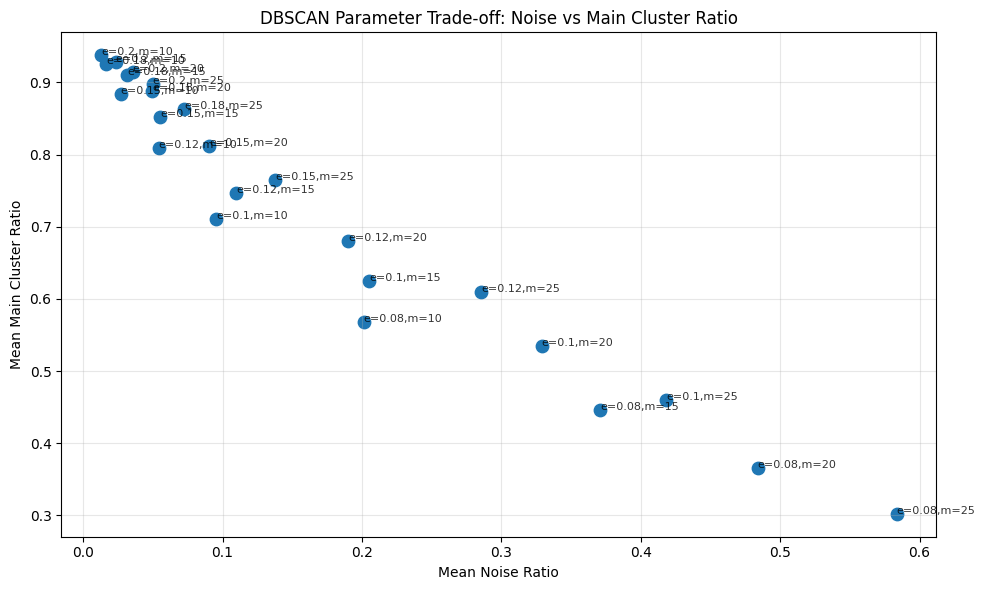

Saved: /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_figures/dbscan_noise_vs_main_cluster_ratio.png


In [15]:
# Cell 13 - Visualisasi ranking DBSCAN

plt.figure(figsize=(10, 6))
plt.scatter(
    rank_df["noise_ratio_mean"],
    rank_df["main_cluster_ratio_total_mean"],
    s=80,
)

for _, r in rank_df.iterrows():
    label = f"e={r['eps']},m={int(r['min_samples'])}"
    plt.text(
        r["noise_ratio_mean"],
        r["main_cluster_ratio_total_mean"],
        label,
        fontsize=8,
        alpha=0.8,
    )

plt.xlabel("Mean Noise Ratio")
plt.ylabel("Mean Main Cluster Ratio")
plt.title("DBSCAN Parameter Trade-off: Noise vs Main Cluster Ratio")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "dbscan_noise_vs_main_cluster_ratio.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print(f"Saved: {fig_path}")

In [16]:
# Cell 14 - Optional visualisasi sample cluster 3D

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly belum tersedia. Install dengan: pip install plotly")


def run_dbscan_for_visual(frame_df: pd.DataFrame, eps: float, min_samples: int):
    """
    Apply cleaning dan DBSCAN untuk visualisasi satu frame.
    Mengembalikan dataframe dengan kolom dbscan_label.
    """
    frame_clean, cleaning_metrics = clean_degenerate_points(frame_df)

    if len(frame_clean) == 0:
        frame_clean["dbscan_label"] = []
        return frame_clean, cleaning_metrics

    if len(frame_clean) < min_samples:
        frame_clean = frame_clean.copy()
        frame_clean["dbscan_label"] = -1
        return frame_clean, cleaning_metrics

    X_feat = frame_clean[DBSCAN_FEATURES].to_numpy(dtype=float)
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_feat)

    frame_clean = frame_clean.copy()
    frame_clean["dbscan_label"] = labels

    return frame_clean, cleaning_metrics


def plot_dbscan_frame_3d(frame_labeled: pd.DataFrame, title: str, max_points=12000):
    if not PLOTLY_AVAILABLE:
        print("Plotly not available.")
        return

    if frame_labeled is None or len(frame_labeled) == 0:
        print("No data to plot.")
        return

    if len(frame_labeled) > max_points:
        plot_df = frame_labeled.sample(max_points, random_state=42)
    else:
        plot_df = frame_labeled.copy()

    labels = plot_df["dbscan_label"].astype(str)

    fig = go.Figure()

    fig.add_trace(
        go.Scatter3d(
            x=plot_df["X_corr"],
            y=plot_df["Y_corr"],
            z=plot_df["Z_level"],
            mode="markers",
            marker=dict(
                size=2,
                color=plot_df["dbscan_label"],
                colorscale="Turbo",
                opacity=0.8,
            ),
            text=labels,
            name="DBSCAN labels",
        )
    )

    fig.update_layout(
        title=f"{title}<br>Points: {len(frame_labeled):,} | Plotted: {len(plot_df):,}",
        scene=dict(
            xaxis=dict(title="X_corr", range=[ROI_X_MIN, ROI_X_MAX]),
            yaxis=dict(title="Y_corr", range=[ROI_Y_MIN, ROI_Y_MAX]),
            zaxis=dict(title="Z_level", range=[ROI_Z_MIN, ROI_Z_MAX]),
            aspectmode="manual",
            aspectratio=dict(x=1.5, y=1.5, z=1.0),
        ),
        width=950,
        height=750,
        margin=dict(l=0, r=0, b=0, t=80),
    )

    fig.show()


# ============================================================
# GANTI BAGIAN INI UNTUK CEK VISUAL
# Contoh:
# CHECK_REL_PATH = "Dataset Development/Duduk/Dilia/3.csv"
# CHECK_FRAME_ID = 31
# ============================================================

CHECK_REL_PATH = "Dataset Development/Duduk/Dilia/3.csv"
CHECK_FRAME_ID = None  # isi frame_id tertentu, atau None untuk frame pertama yang tersedia

# Gunakan parameter recommended dari best_config
VIS_EPS = best_config["eps"]
VIS_MIN_SAMPLES = best_config["min_samples"]

check_path = DBSCAN_INPUT_DIR / CHECK_REL_PATH

print("===== VISUAL CHECK CONFIG =====")
print(f"Path        : {check_path}")
print(f"Exists      : {check_path.exists()}")
print(f"Frame ID    : {CHECK_FRAME_ID}")
print(f"eps         : {VIS_EPS}")
print(f"min_samples : {VIS_MIN_SAMPLES}")

if check_path.exists():
    check_df = pd.read_csv(check_path)

    if len(check_df) == 0:
        print("Selected file is empty.")
    else:
        available_frames = sorted(check_df["frame_id"].dropna().unique().tolist())

        if CHECK_FRAME_ID is None:
            selected_frame_id = available_frames[len(available_frames) // 2]
        else:
            selected_frame_id = CHECK_FRAME_ID

        frame_df = check_df[check_df["frame_id"] == selected_frame_id].copy()

        frame_labeled, cleaning_metrics = run_dbscan_for_visual(
            frame_df=frame_df,
            eps=VIS_EPS,
            min_samples=VIS_MIN_SAMPLES,
        )

        print("Cleaning metrics:", cleaning_metrics)
        print("Frame points before:", len(frame_df))
        print("Frame points after cleaning:", len(frame_labeled))

        if "dbscan_label" in frame_labeled.columns:
            print("DBSCAN label counts:")
            display(frame_labeled["dbscan_label"].value_counts().reset_index().rename(
                columns={"index": "dbscan_label", "dbscan_label": "count"}
            ))

        plot_dbscan_frame_3d(
            frame_labeled,
            title=f"DBSCAN Visual Check | {CHECK_REL_PATH} | frame={selected_frame_id} | eps={VIS_EPS}, min_samples={VIS_MIN_SAMPLES}",
        )

===== VISUAL CHECK CONFIG =====
Path        : /media/spell/Spell-lab/Lidar/D.Preprocessing/Preprocessed_GC25_Z008/GC25_Z080/Dataset Development/Duduk/Dilia/3.csv
Exists      : True
Frame ID    : None
eps         : 0.2
min_samples : 10
Cleaning metrics: {'n_points_before_cleaning': 1013, 'n_non_finite_removed': 0, 'n_corr_all_zero_removed': 337, 'n_raw_all_zero_removed': 337, 'n_all_zero_removed': 337, 'n_points_after_cleaning': 676, 'cleaning_removed_ratio': 0.33267522211253703}
Frame points before: 1013
Frame points after cleaning: 676
DBSCAN label counts:


,count,count
0,0,672
1,-1,4


In [17]:
# Cell 15 - Optional visualisasi beberapa kandidat top ranking

# Cell ini membantu membandingkan 3 kandidat teratas pada frame yang sama.

TOP_K_VIS = 3

if check_path.exists() and len(rank_df) > 0:
    check_df = pd.read_csv(check_path)

    if len(check_df) > 0:
        available_frames = sorted(check_df["frame_id"].dropna().unique().tolist())

        if CHECK_FRAME_ID is None:
            selected_frame_id = available_frames[len(available_frames) // 2]
        else:
            selected_frame_id = CHECK_FRAME_ID

        frame_df = check_df[check_df["frame_id"] == selected_frame_id].copy()

        top_candidates = rank_df.head(TOP_K_VIS)

        for _, cand in top_candidates.iterrows():
            eps = float(cand["eps"])
            min_samples = int(cand["min_samples"])

            frame_labeled, cleaning_metrics = run_dbscan_for_visual(
                frame_df=frame_df,
                eps=eps,
                min_samples=min_samples,
            )

            print("=" * 80)
            print(f"Candidate rank: {int(cand['rank'])}")
            print(f"eps={eps}, min_samples={min_samples}, auto_score={cand['auto_score']:.4f}")
            print("Cleaning:", cleaning_metrics)

            if "dbscan_label" in frame_labeled.columns:
                print("Label counts:")
                display(frame_labeled["dbscan_label"].value_counts().reset_index().rename(
                    columns={"index": "dbscan_label", "dbscan_label": "count"}
                ))

            plot_dbscan_frame_3d(
                frame_labeled,
                title=f"Top Candidate Rank {int(cand['rank'])} | eps={eps}, min_samples={min_samples} | frame={selected_frame_id}",
            )

Candidate rank: 1
eps=0.2, min_samples=10, auto_score=0.8211
Cleaning: {'n_points_before_cleaning': 1013, 'n_non_finite_removed': 0, 'n_corr_all_zero_removed': 337, 'n_raw_all_zero_removed': 337, 'n_all_zero_removed': 337, 'n_points_after_cleaning': 676, 'cleaning_removed_ratio': 0.33267522211253703}
Label counts:


,count,count
0,0,672
1,-1,4


Candidate rank: 2
eps=0.2, min_samples=15, auto_score=0.8152
Cleaning: {'n_points_before_cleaning': 1013, 'n_non_finite_removed': 0, 'n_corr_all_zero_removed': 337, 'n_raw_all_zero_removed': 337, 'n_all_zero_removed': 337, 'n_points_after_cleaning': 676, 'cleaning_removed_ratio': 0.33267522211253703}
Label counts:


,count,count
0,0,672
1,-1,4


Candidate rank: 3
eps=0.18, min_samples=10, auto_score=0.7967
Cleaning: {'n_points_before_cleaning': 1013, 'n_non_finite_removed': 0, 'n_corr_all_zero_removed': 337, 'n_raw_all_zero_removed': 337, 'n_all_zero_removed': 337, 'n_points_after_cleaning': 676, 'cleaning_removed_ratio': 0.33267522211253703}
Label counts:


,count,count
0,0,672
1,-1,4


In [18]:
# Cell 16 - Final checklist DBSCAN tuning

print("===== FINAL DBSCAN TUNING CHECKLIST =====")

print(f"Input folder              : {DBSCAN_INPUT_DIR}")
print(f"Output folder             : {DBSCAN_OUT_DIR}")
print(f"Per-frame metrics         : {per_frame_metrics_path}")
print(f"Summary global            : {summary_global_path}")
print(f"Ranking                   : {rank_path}")
print(f"Best config               : {best_config_path}")
print(f"File logs                 : {file_logs_path}")

print("\nRecommended DBSCAN:")
print(f"eps                       : {best_config['eps']}")
print(f"min_samples               : {best_config['min_samples']}")
print(f"min_cluster_points         : {best_config['min_cluster_points']}")

print("\nImportant reminder:")
print("- Best config ini adalah rekomendasi otomatis berdasarkan auto_score.")
print("- Tetap cek summary table dan visual sample sebelum mengunci parameter final.")
print("- Setelah final eps/min_samples dipilih, buat notebook terpisah untuk Apply DBSCAN Final.")

===== FINAL DBSCAN TUNING CHECKLIST =====
Input folder              : /media/spell/Spell-lab/Lidar/D.Preprocessing/Preprocessed_GC25_Z008/GC25_Z080
Output folder             : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080
Per-frame metrics         : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_per_frame.csv
Summary global            : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_summary.csv
Ranking                   : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/dbscan_sweep_ranking.csv
Best config               : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_metrics/best_dbscan_config.json
File logs                 : /media/spell/Spell-lab/Lidar/D.Preprocessing/DBSCAN_Calibration_GC25_Z080/_logs/dbscan_file_logs.csv

Recommended DBSCAN:
eps                       : 0.2
min_samples            